# Интерпретация

## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

## Подготовка данных и моделей

In [8]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

# Загрузка данных
data = pd.read_csv("data_unreg.csv")

# Признаки
num_features = [
    "location_marketplace_cnt",
    "location_amenity_pharmacy_w_mean_distance",
    "location_public_transport_stop_position_cnt",
    "location_college_cnt",
    "location_railway_cnt",
    "location_logs_count_std",
    "location_leisure_cnt",
    "location_shop_product_w_mean_distance",
    "location_public_transport_platform_w_mean_distance",
    "location_leisure_w_mean_distance",
    "location_flash_mean_mean",
    "location_market_cnt",
    "location_barrier_w_mean_distance",
]
cat_features = [
    "region_name_cat", "class_cat", "district_cat",
    "hc_name_cat", "developer_cat", "corpus_cat", "stage_cat",
]

X = data.drop(columns=["price_target"])
y = data["price_target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Pipeline-модели
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  MinMaxScaler()),
])
cat_pipeline = Pipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
])

lin_model = Pipeline([("preprocessor", preprocessor),
                       ("model", LinearRegression())])
gb_model  = Pipeline([("preprocessor", preprocessor),
                       ("model", GradientBoostingRegressor(max_depth=5, random_state=42))])

lin_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("Модели обучены")
print(f"  Train: {X_train.shape}  |  Test: {X_test.shape}")


Модели обучены
  Train: (23924, 82)  |  Test: (5981, 82)


## Признак 1

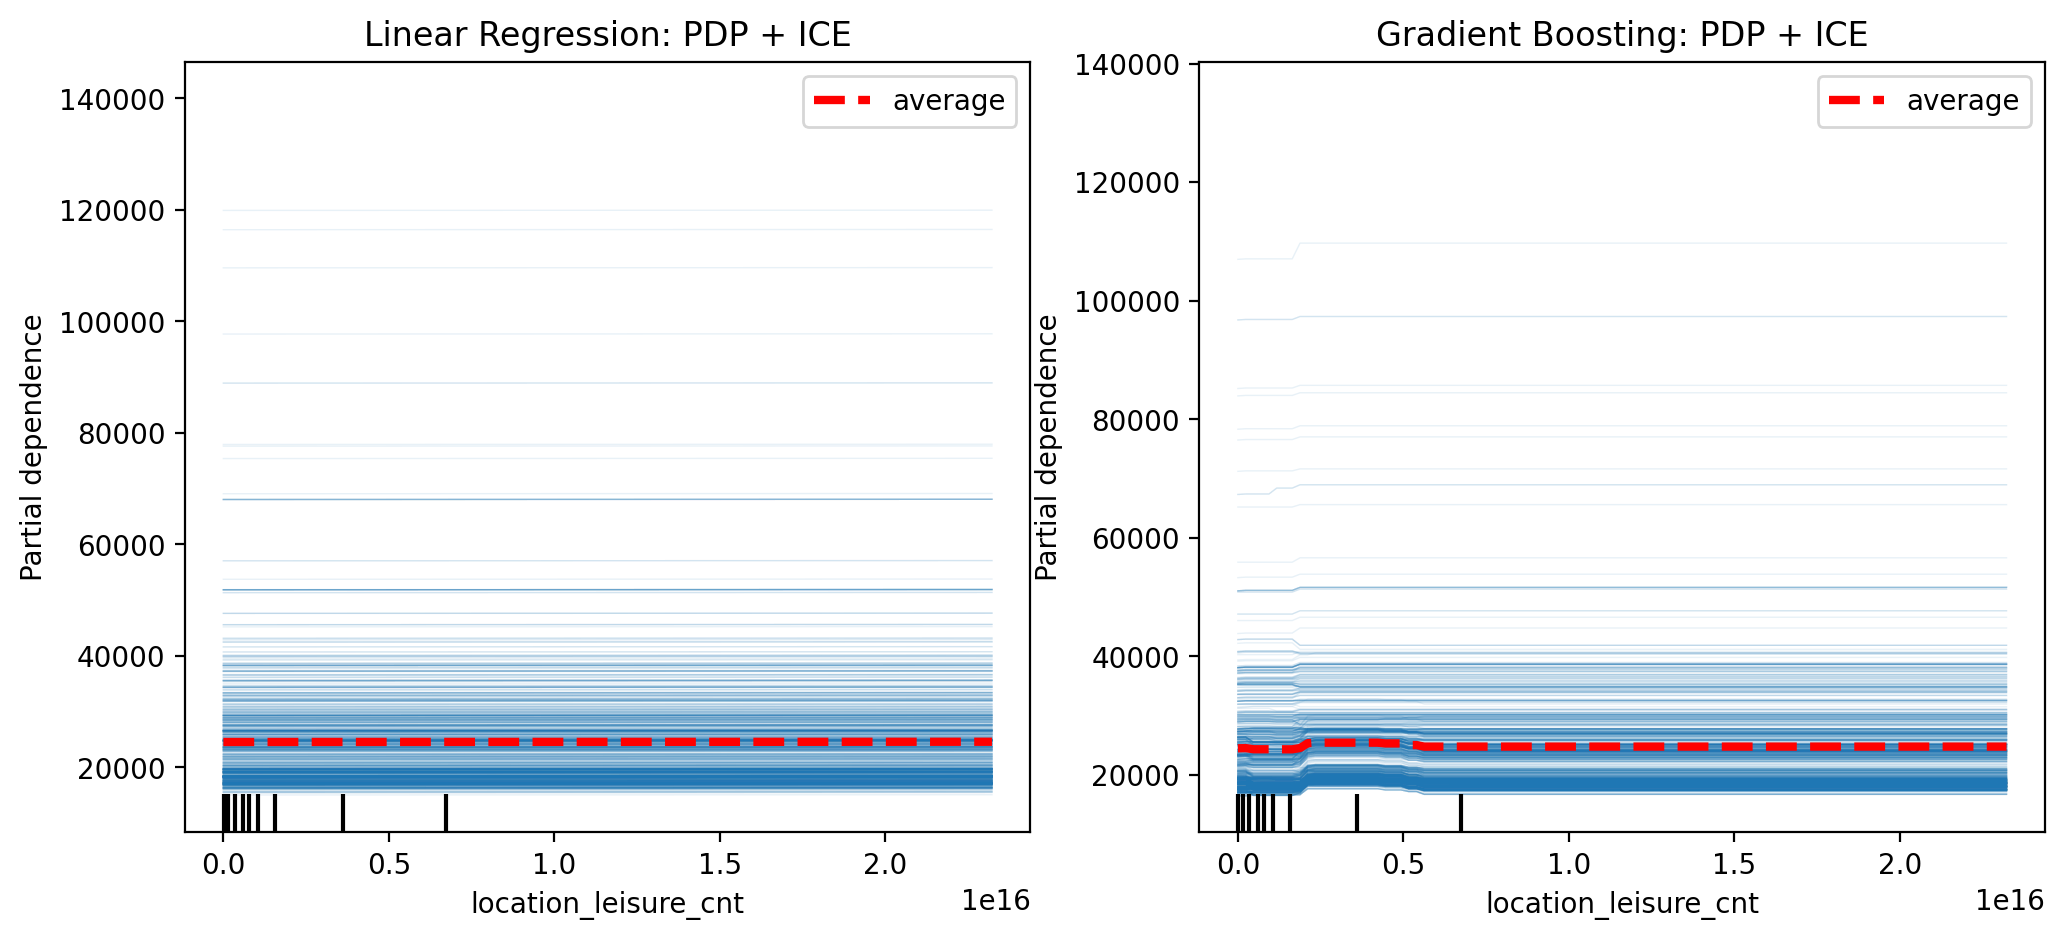

In [9]:
feature = "location_leisure_cnt"

fig, ax = plt.subplots(1,2, figsize=(12,5))

PartialDependenceDisplay.from_estimator(
    lin_model,
    X_train,
    [feature],
    kind="both",
    pd_line_kw={"color": "red", "linewidth": 3},   
    ice_lines_kw={"alpha": 0.1},                 
    ax=ax[0]
)

ax[0].set_title("Linear Regression: PDP + ICE")

PartialDependenceDisplay.from_estimator(
    gb_model,
    X_train,
    [feature],
    kind="both",
    pd_line_kw={"color": "red", "linewidth": 3},   
    ice_lines_kw={"alpha": 0.1},                   
    ax=ax[1]
)

ax[1].set_title("Gradient Boosting: PDP + ICE")

plt.show()

## Признак 1 (с выбросами)

In [10]:
X_outliers = X_train.copy()

outliers = X_outliers.sample(100).copy()
outliers["location_leisure_cnt"] = outliers["location_leisure_cnt"] * 20

X_outliers = pd.concat([X_outliers, outliers])

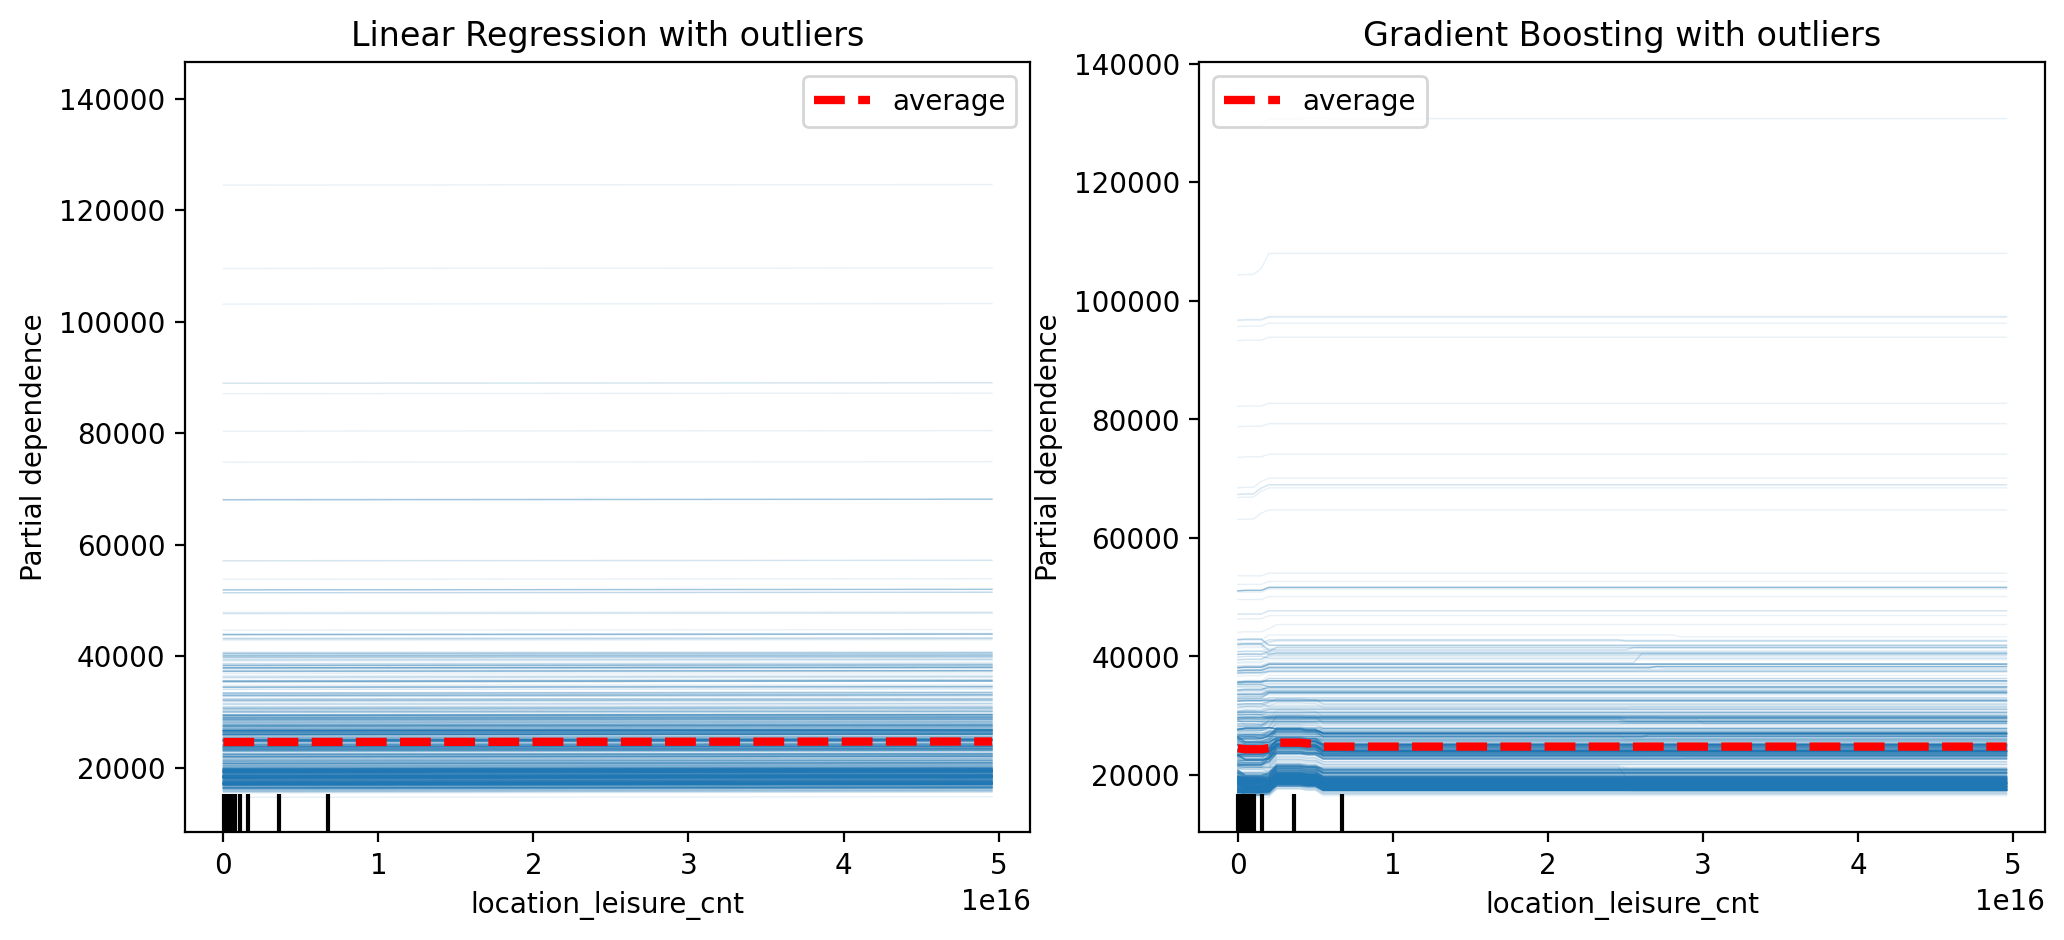

In [11]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

PartialDependenceDisplay.from_estimator(
    lin_model,
    X_outliers,
    [feature],
    kind="both",
    pd_line_kw={"color": "red", "linewidth": 3},   
    ice_lines_kw={"alpha": 0.1},                   
    ax=ax[0]
)

ax[0].set_title("Linear Regression with outliers")

PartialDependenceDisplay.from_estimator(
    gb_model,
    X_outliers,
    [feature],
    kind="both",
    pd_line_kw={"color": "red", "linewidth": 3},   
    ice_lines_kw={"alpha": 0.1},                
    ax=ax[1]
)

ax[1].set_title("Gradient Boosting with outliers")

plt.show()

## Признак 2

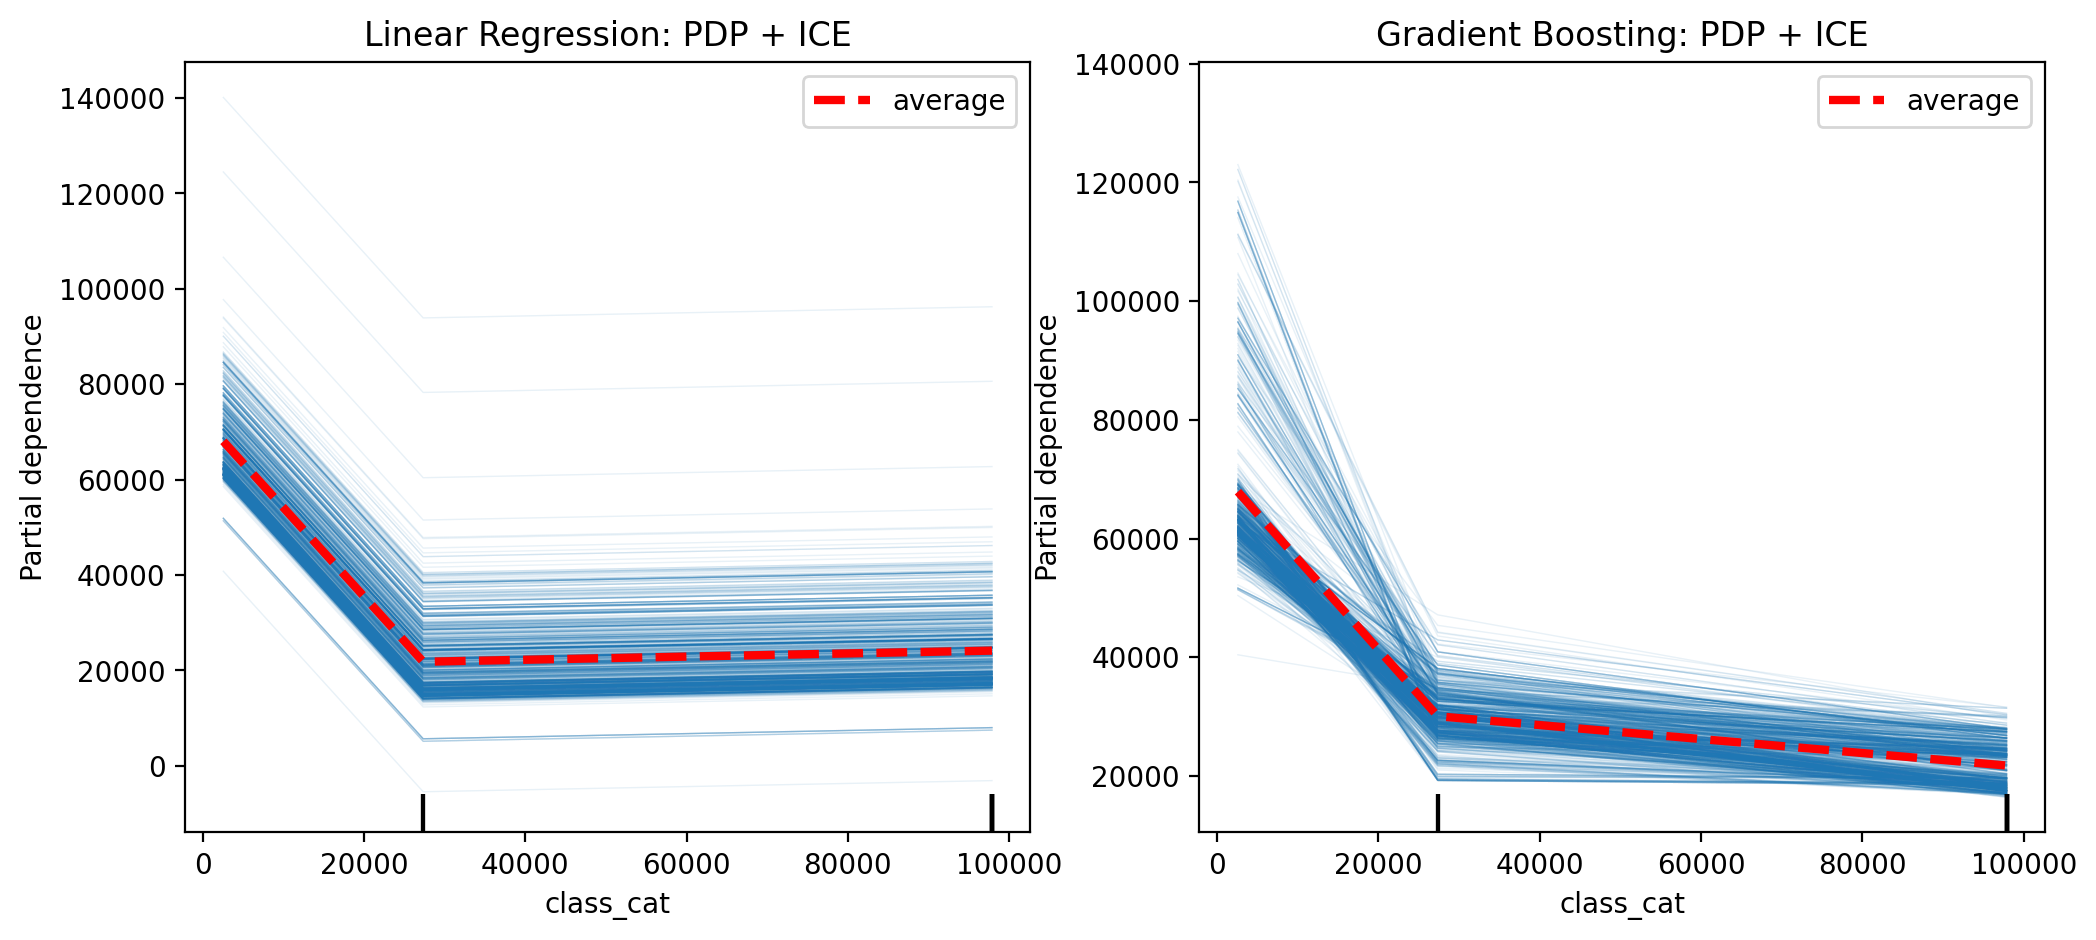

In [12]:
feature = "class_cat"

fig, ax = plt.subplots(1,2, figsize=(12,5))

PartialDependenceDisplay.from_estimator(
    lin_model,
    X_train,
    [feature],
    kind="both",
    pd_line_kw={"color": "red", "linewidth": 3},  
    ice_lines_kw={"alpha": 0.1},                
    ax=ax[0]
)

ax[0].set_title("Linear Regression: PDP + ICE")

PartialDependenceDisplay.from_estimator(
    gb_model,
    X_train,
    [feature],
    kind="both",
    pd_line_kw={"color": "red", "linewidth": 3},  
    ice_lines_kw={"alpha": 0.1},            
    ax=ax[1]
)

ax[1].set_title("Gradient Boosting: PDP + ICE")

plt.show()

## Признак 2 (с выбросами)

In [13]:
X_outliers = X_train.copy()

outliers = X_outliers.sample(100).copy()
outliers["class_cat"] = outliers["class_cat"] * 20

X_outliers = pd.concat([X_outliers, outliers])

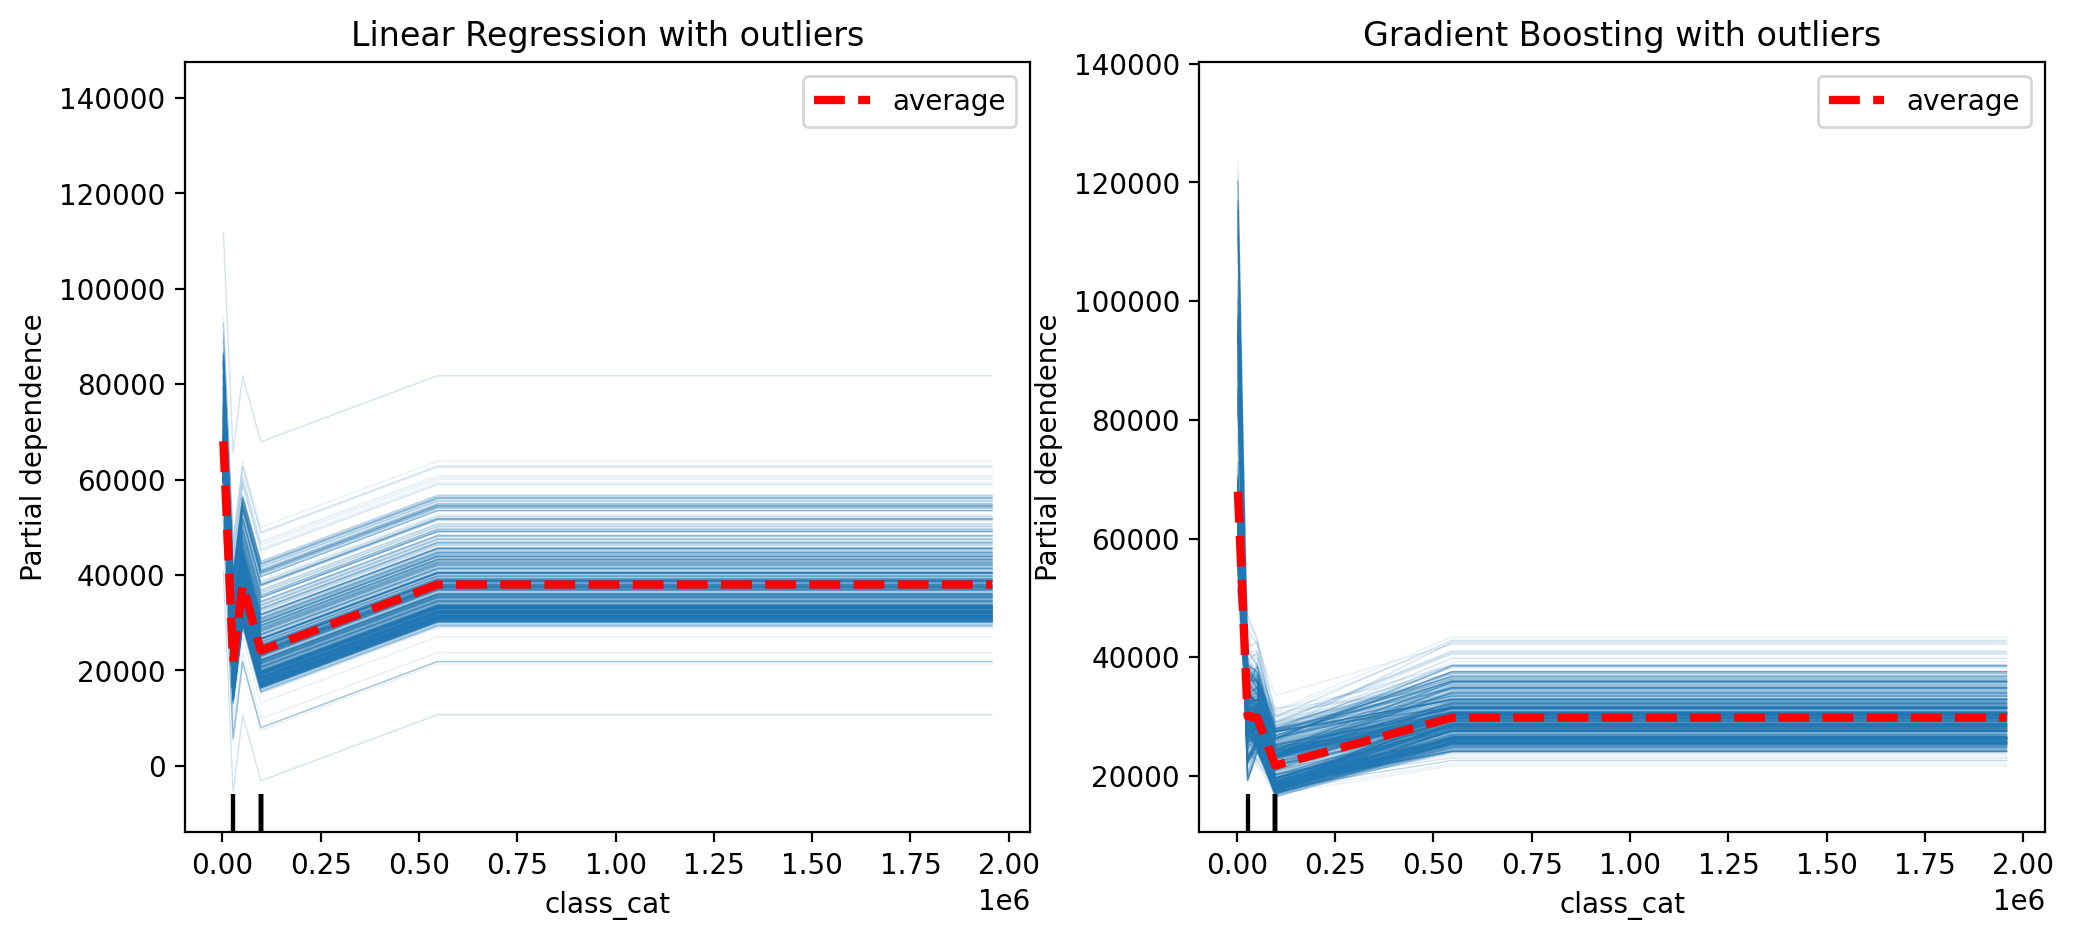

In [14]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

PartialDependenceDisplay.from_estimator(
    lin_model,
    X_outliers,
    [feature],
    kind="both",
    pd_line_kw={"color": "red", "linewidth": 3},  
    ice_lines_kw={"alpha": 0.1},                 
    ax=ax[0]
)

ax[0].set_title("Linear Regression with outliers")

PartialDependenceDisplay.from_estimator(
    gb_model,
    X_outliers,
    [feature],
    kind="both",
    pd_line_kw={"color": "red", "linewidth": 3},  
    ice_lines_kw={"alpha": 0.1},                   
    ax=ax[1]
)

ax[1].set_title("Gradient Boosting with outliers")

plt.show()

### Поведение моделей на исходных данных

Линии ICE для числовых признаков получаются параллельными прямыми для линейной регрессии и линиями с небольшими переломами для ГБ.
Для категориальных признаков линии имеют ломаную форму, что связано с тем, что модель меняет основу предсказания в зависимости от значений признака (класса).

### Что происходит при выходе признака за исходный диапазон

После искусственного добавления выбросов (значений площади, выходящих за исходный диапазон) поведение моделей отличается:

**LinearRegression**

Линейная регрессия продолжает линейную зависимость и **экстраполирует предсказания за пределами обучающих данных**.  
Это означает, что при увеличении значения признака модель будет продолжать изменять предсказание по той же линейной зависимости, даже если такие значения не встречались в обучающей выборке.

**Gradient Boosting**

Градиентный бустинг ведёт себя иначе. Поскольку модель состоит из решающих деревьев, она делает предсказания на основе разбиений признака на интервалы.  
Если значение признака выходит за пределы диапазона обучающих данных, модель **использует последнее известное разбиение**, поэтому предсказание остаётся почти постоянным.
